# Per-Patient Time Trends: Firing Rate & Amplitude

Six visualisation variants for each feature, showing individual patient slopes
across the experiment.

| # | Blocks included | Normalization |
|---|----------------|---------------|
| 1 | All (BL + stim + pause) | Raw |
| 2 | BL + stim only | Raw |
| 3 | All | % change from baseline |
| 4 | BL + stim only | % change from baseline |
| 5 | All | % change from mean pause |
| 6 | BL + stim only | % change from mean pause |

Each plot: one line per patient (blue = negative slope, red = positive),
plus a thick black line for the group-average slope.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import warnings

warnings.filterwarnings('ignore')
sns.set(style='white', context='talk')
print('Setup done.')

Setup done.


## 1. Load & reshape data

In [2]:
RATE_PATH = r'final_firing_rates_wide.csv'
AMP_PATH  = r'final_amplitudes_wide.csv'


def load_and_melt(path, value_name):
    df = pd.read_csv(path)
    block_cols = [c for c in df.columns if c != 'Subject_ID']
    long = df.melt(id_vars='Subject_ID', value_vars=block_cols,
                   var_name='block_label', value_name=value_name)
    long = long.dropna(subset=[value_name]).copy()
    long['block_number'] = long['block_label'].apply(
        lambda x: 0 if x == 'BL' else int(x.split('_')[1]))

    def _type(label):
        if label == 'BL':
            return 'baseline'
        num = int(label.split('_')[1])
        return 'stim' if num % 2 == 1 else 'pause'

    long['block_type'] = long['block_label'].apply(_type)
    long['Subject_ID'] = long['Subject_ID'].astype(str)
    long = long.sort_values(['Subject_ID', 'block_number']).reset_index(drop=True)
    return long


df_rate = load_and_melt(RATE_PATH, 'firing_rate')
df_amp  = load_and_melt(AMP_PATH,  'amplitude')

# Check which subjects have baseline
rate_has_bl = set(df_rate[df_rate['block_type'] == 'baseline']['Subject_ID'].unique())
amp_has_bl  = set(df_amp[df_amp['block_type'] == 'baseline']['Subject_ID'].unique())
print(f'Rate subjects with BL: {sorted(rate_has_bl)}')
print(f'Amp  subjects with BL: {sorted(amp_has_bl)}')
print(f'Rate subjects without BL: {sorted(set(df_rate.Subject_ID.unique()) - rate_has_bl)}')
print(f'Amp  subjects without BL: {sorted(set(df_amp.Subject_ID.unique()) - amp_has_bl)}')

Rate subjects with BL: ['485', '486', '487', '488', '497', '498', '499', '505', '5107', '520']
Amp  subjects with BL: ['485', '486', '487', '488', '497', '498', '499', '505', '5107', '520']
Rate subjects without BL: ['515', '545']
Amp  subjects without BL: ['515', '545']


---
## 2. Core plotting function

In [3]:
def plot_patient_slopes(df, dv, title, ylabel,
                       block_filter=None, normalize=None,
                       exclude_no_bl=False):
    """
    Plot per-patient slopes across block numbers.

    Parameters
    ----------
    df : DataFrame in long format
    dv : column name of the dependent variable
    title : plot title
    ylabel : y-axis label
    block_filter : None | 'stim_only'
        If 'stim_only', keep only baseline + stim blocks (drop pause).
    normalize : None | 'baseline_pct' | 'pause_pct'
    exclude_no_bl : if True, drop subjects without a baseline value.
    """
    data = df.copy()

    # ── Filter blocks ──
    if block_filter == 'stim_only':
        data = data[data['block_type'].isin(['baseline', 'stim'])].copy()

    # ── Identify subjects with/without baseline ──
    subjs_with_bl = set(data[data['block_type'] == 'baseline']['Subject_ID'].unique())

    if exclude_no_bl:
        data = data[data['Subject_ID'].isin(subjs_with_bl)].copy()

    # ── Normalize ──
    if normalize == 'baseline_pct':
        # % change from baseline
        bl_vals = (data[data['block_type'] == 'baseline']
                   .groupby('Subject_ID')[dv].mean().to_dict())
        data['_bl'] = data['Subject_ID'].map(bl_vals)
        data[dv] = ((data[dv] - data['_bl']) / data['_bl']) * 100
        data = data.drop(columns='_bl')

    elif normalize == 'pause_pct':
        # % change from mean pause value
        pause_means = (data[data['block_type'] == 'pause']
                       .groupby('Subject_ID')[dv].mean())
        # For stim_only filter there are no pause blocks; use from full df
        if pause_means.empty:
            pause_means = (df[df['block_type'] == 'pause']
                           .groupby('Subject_ID')[dv].mean())
        pm_dict = pause_means.to_dict()
        data['_pm'] = data['Subject_ID'].map(pm_dict)
        data[dv] = ((data[dv] - data['_pm']) / data['_pm']) * 100
        data = data.drop(columns='_pm')
        # drop subjects with no pause data
        data = data.dropna(subset=[dv])

    # ── For subjects without BL, re-index so first block = 1 ──
    # (they already start at block 1 naturally)

    # ── Compute per-patient slopes ──
    subjects = sorted(data['Subject_ID'].unique())
    slopes = {}
    intercepts = {}
    x_ranges = {}

    for subj in subjects:
        sub = data[data['Subject_ID'] == subj].sort_values('block_number')
        if len(sub) < 2:
            continue
        x = sub['block_number'].values.astype(float)
        y = sub[dv].values.astype(float)
        # remove NaN/inf
        mask = np.isfinite(y)
        x, y = x[mask], y[mask]
        if len(x) < 2:
            continue
        res = linregress(x, y)
        slopes[subj] = res.slope
        intercepts[subj] = res.intercept
        x_ranges[subj] = (x.min(), x.max())

    if not slopes:
        print(f'  No valid slopes for: {title}')
        return

    # ── Average slope ──
    avg_slope = np.mean(list(slopes.values()))

    # ── Average intercept (for the avg line) ──
    avg_intercept = np.mean(list(intercepts.values()))

    # ── Global x range ──
    global_xmin = min(r[0] for r in x_ranges.values())
    global_xmax = max(r[1] for r in x_ranges.values())

    # ── Plot ──
    fig, ax = plt.subplots(figsize=(10, 6))

    for subj in subjects:
        if subj not in slopes:
            continue
        s = slopes[subj]
        b = intercepts[subj]
        xmin, xmax = x_ranges[subj]
        color = '#d9534f' if s > 0 else '#4a90d9'  # red positive, blue negative
        x_line = np.array([xmin, xmax])
        ax.plot(x_line, b + s * x_line,
                color=color, alpha=0.4, linewidth=1.5)

        # scatter the actual data points
        sub = data[data['Subject_ID'] == subj]
        ax.scatter(sub['block_number'], sub[dv],
                   color=color, alpha=0.3, s=15, edgecolors='none')

    # ── Average slope line ──
    x_avg = np.array([global_xmin, global_xmax])
    ax.plot(x_avg, avg_intercept + avg_slope * x_avg,
            color='black', linewidth=3, linestyle='-',
            label=f'Avg slope = {avg_slope:.3f}', zorder=10)

    # ── Formatting ──
    n_pos = sum(1 for s in slopes.values() if s > 0)
    n_neg = sum(1 for s in slopes.values() if s <= 0)
    ax.set_title(f'{title}\n'
                 f'N={len(slopes)} patients  |  '
                 f'{n_neg} negative (blue), {n_pos} positive (red)  |  '
                 f'Avg slope = {avg_slope:.4f}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Block Number', fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13, fontweight='bold')
    ax.legend(fontsize=11, loc='best')

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)

    plt.tight_layout()
    plt.show()

    # Print individual slopes
    print(f'\nPer-patient slopes for: {title}')
    for subj in sorted(slopes.keys()):
        direction = '+' if slopes[subj] > 0 else '-'
        print(f'  {subj}: {slopes[subj]:+.4f} ({direction})')
    print(f'  --- Average: {avg_slope:+.4f}')
    print()

---
## 3. Firing Rate – Time Trends

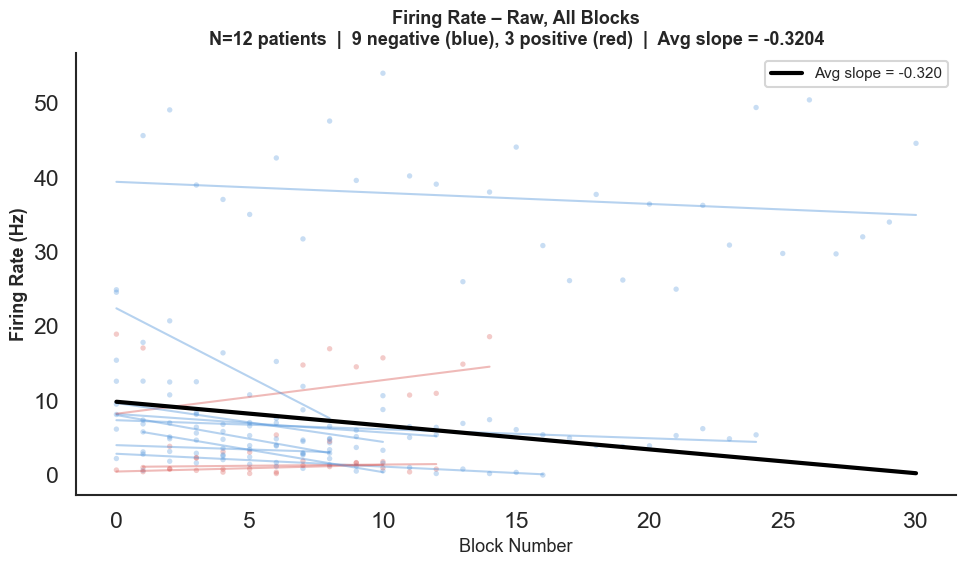


Per-patient slopes for: Firing Rate – Raw, All Blocks
  485: -0.6406 (-)
  486: -0.1167 (-)
  487: -0.2492 (-)
  488: +0.4520 (+)
  497: -0.1485 (-)
  498: -0.1215 (-)
  499: -0.1726 (-)
  505: -0.5226 (-)
  5107: +0.0899 (+)
  515: +0.0322 (+)
  520: -1.8480 (-)
  545: -0.5991 (-)
  --- Average: -0.3204


In [4]:
# 1) Raw, all blocks
plot_patient_slopes(df_rate, 'firing_rate',
    title='Firing Rate – Raw, All Blocks',
    ylabel='Firing Rate (Hz)')

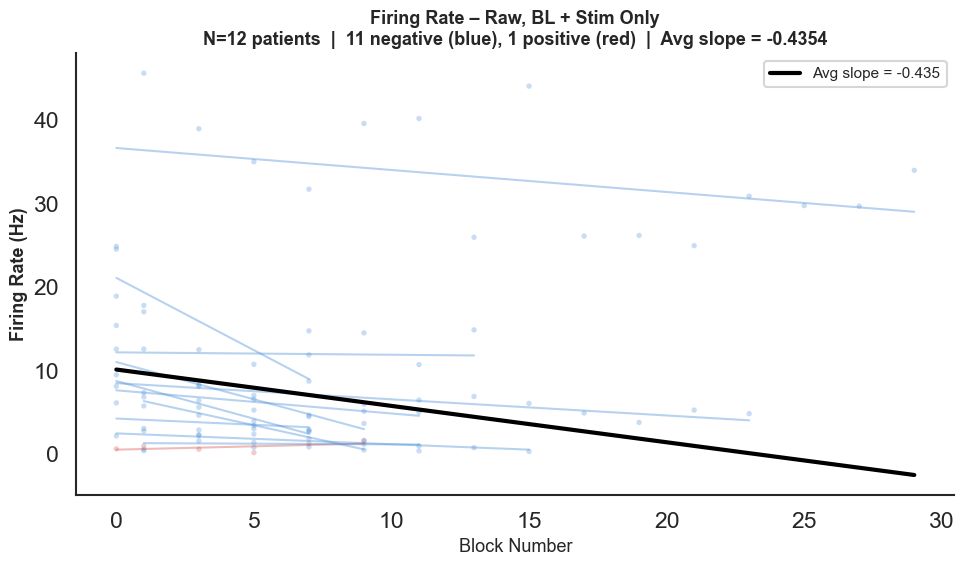


Per-patient slopes for: Firing Rate – Raw, BL + Stim Only
  485: -0.9039 (-)
  486: -0.1487 (-)
  487: -0.2773 (-)
  488: -0.0285 (-)
  497: -0.2633 (-)
  498: -0.1935 (-)
  499: -0.1297 (-)
  505: -0.8927 (-)
  5107: +0.0809 (+)
  515: -0.0161 (-)
  520: -1.7307 (-)
  545: -0.7217 (-)
  --- Average: -0.4354


In [5]:
# 2) Raw, BL + stim only
plot_patient_slopes(df_rate, 'firing_rate',
    title='Firing Rate – Raw, BL + Stim Only',
    ylabel='Firing Rate (Hz)',
    block_filter='stim_only')

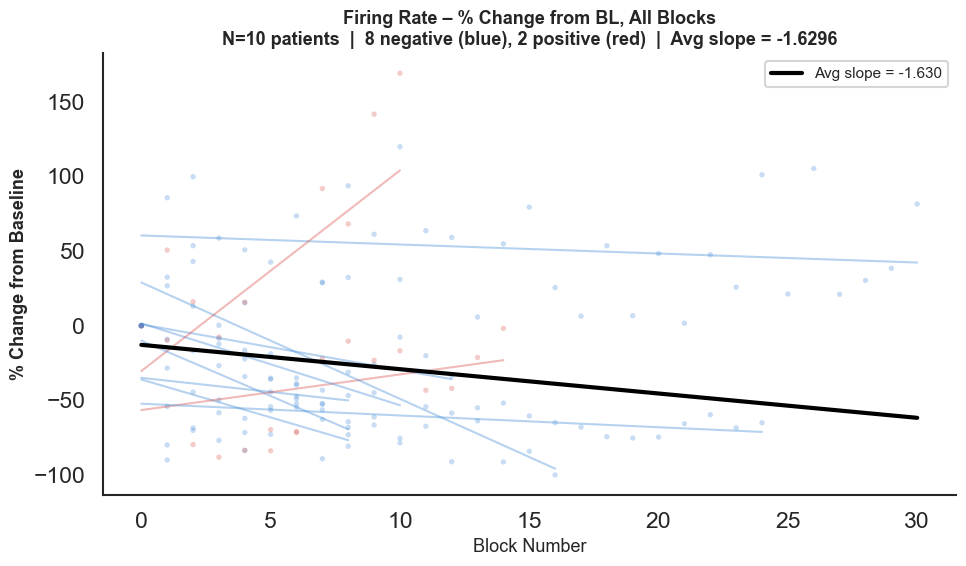


Per-patient slopes for: Firing Rate – % Change from BL, All Blocks
  485: -5.0800 (-)
  486: -1.8918 (-)
  487: -3.0612 (-)
  488: +2.3865 (+)
  497: -0.6044 (-)
  498: -0.7874 (-)
  499: -7.7931 (-)
  505: -5.4847 (-)
  5107: +13.4387 (+)
  520: -7.4186 (-)
  --- Average: -1.6296


In [6]:
# 3) Baseline-normalized %, all blocks
plot_patient_slopes(df_rate, 'firing_rate',
    title='Firing Rate – % Change from BL, All Blocks',
    ylabel='% Change from Baseline',
    normalize='baseline_pct', exclude_no_bl=True)

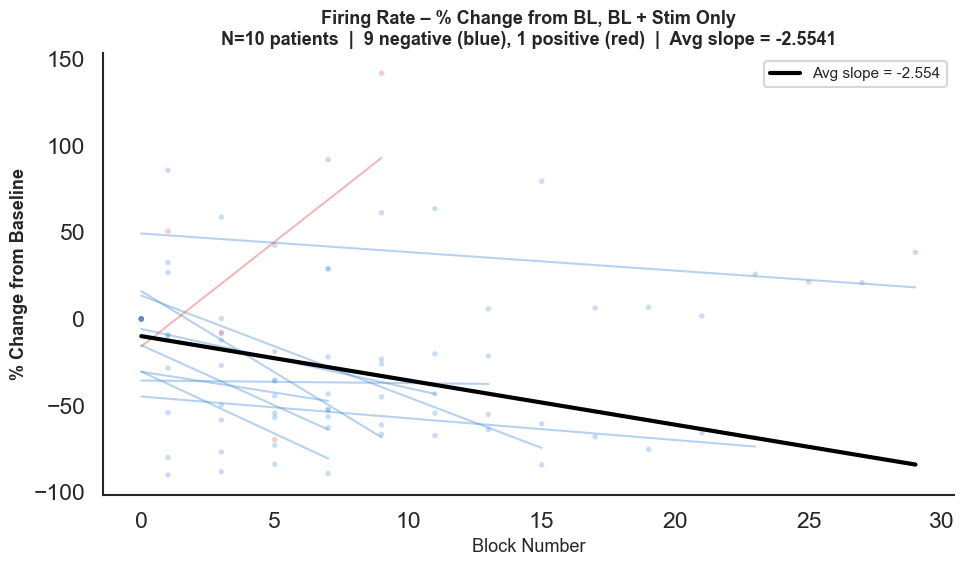


Per-patient slopes for: Firing Rate – % Change from BL, BL + Stim Only
  485: -7.1677 (-)
  486: -2.4113 (-)
  487: -3.4060 (-)
  488: -0.1503 (-)
  497: -1.0713 (-)
  498: -1.2536 (-)
  499: -5.8587 (-)
  505: -9.3678 (-)
  5107: +12.0937 (+)
  520: -6.9477 (-)
  --- Average: -2.5541


In [7]:
# 4) Baseline-normalized %, BL + stim only
plot_patient_slopes(df_rate, 'firing_rate',
    title='Firing Rate – % Change from BL, BL + Stim Only',
    ylabel='% Change from Baseline',
    block_filter='stim_only',
    normalize='baseline_pct', exclude_no_bl=True)

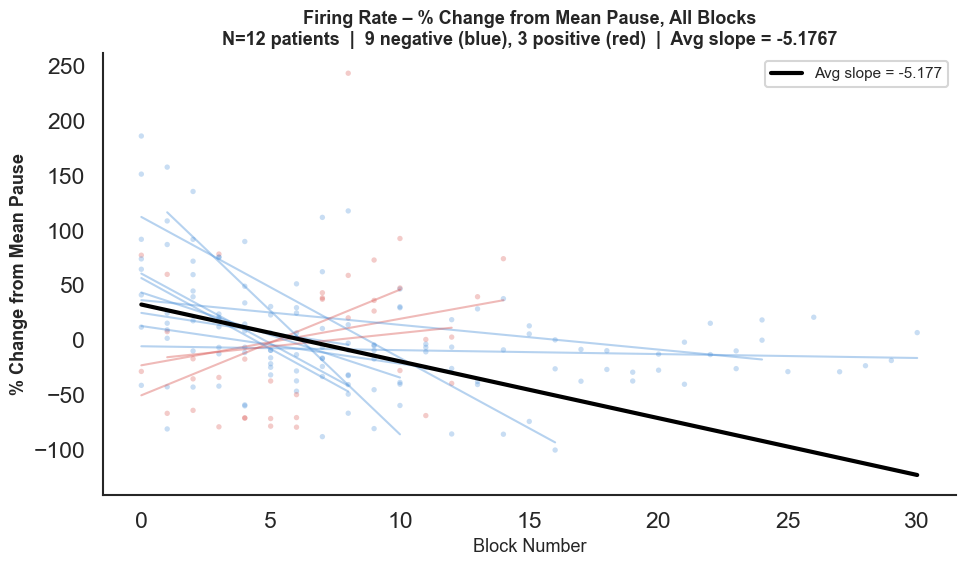


Per-patient slopes for: Firing Rate – % Change from Mean Pause, All Blocks
  485: -12.7709 (-)
  486: -3.6324 (-)
  487: -3.4289 (-)
  488: +4.2366 (+)
  497: -0.3563 (-)
  498: -2.2530 (-)
  499: -12.8372 (-)
  505: -7.7535 (-)
  5107: +9.6265 (+)
  515: +2.4447 (+)
  520: -12.9191 (-)
  545: -22.4771 (-)
  --- Average: -5.1767


In [8]:
# 5) Pause-normalized %, all blocks
plot_patient_slopes(df_rate, 'firing_rate',
    title='Firing Rate – % Change from Mean Pause, All Blocks',
    ylabel='% Change from Mean Pause',
    normalize='pause_pct')

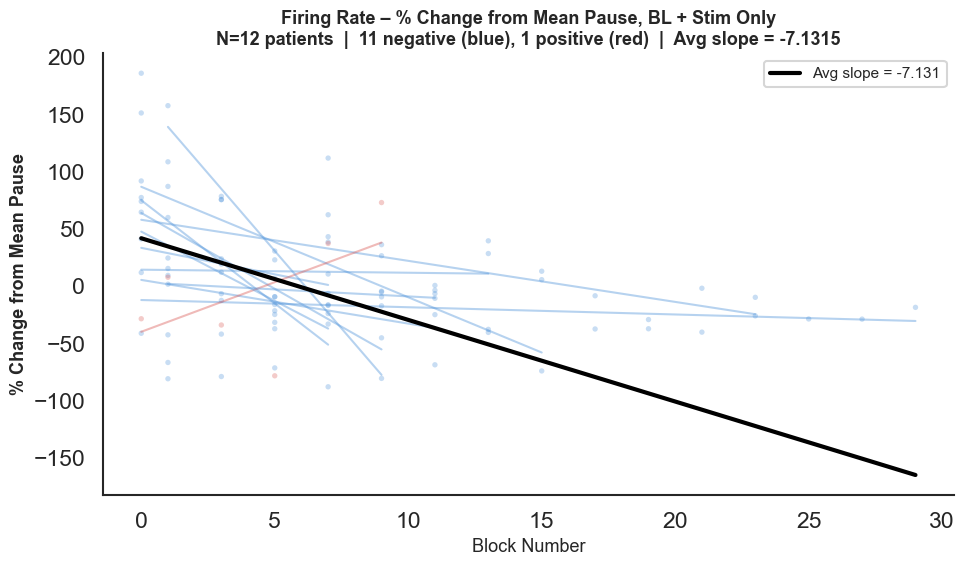


Per-patient slopes for: Firing Rate – % Change from Mean Pause, BL + Stim Only
  485: -18.0194 (-)
  486: -4.6299 (-)
  487: -3.8152 (-)
  488: -0.2668 (-)
  497: -0.6315 (-)
  498: -3.5866 (-)
  499: -9.6508 (-)
  505: -13.2430 (-)
  5107: +8.6631 (+)
  515: -1.2211 (-)
  520: -12.0991 (-)
  545: -27.0774 (-)
  --- Average: -7.1315


In [9]:
# 6) Pause-normalized %, BL + stim only
plot_patient_slopes(df_rate, 'firing_rate',
    title='Firing Rate – % Change from Mean Pause, BL + Stim Only',
    ylabel='% Change from Mean Pause',
    block_filter='stim_only',
    normalize='pause_pct')

---
## 4. Amplitude – Time Trends

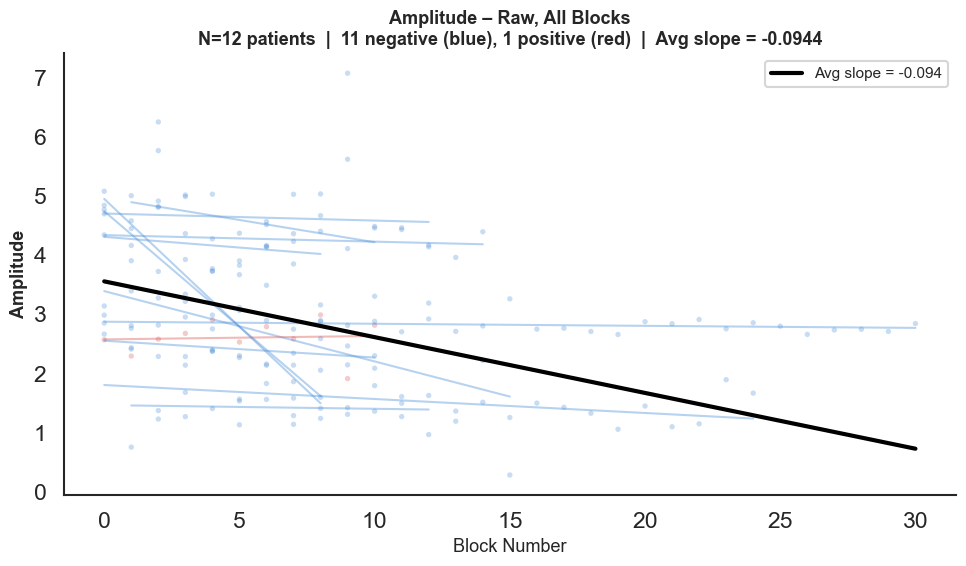


Per-patient slopes for: Amplitude – Raw, All Blocks
  485: -0.3909 (-)
  486: -0.0362 (-)
  487: -0.0119 (-)
  488: -0.0110 (-)
  497: -0.0035 (-)
  498: -0.0237 (-)
  499: -0.1189 (-)
  505: +0.0058 (+)
  5107: -0.0284 (-)
  515: -0.0063 (-)
  520: -0.4321 (-)
  545: -0.0753 (-)
  --- Average: -0.0944


In [10]:
# 1) Raw, all blocks
plot_patient_slopes(df_amp, 'amplitude',
    title='Amplitude – Raw, All Blocks',
    ylabel='Amplitude')

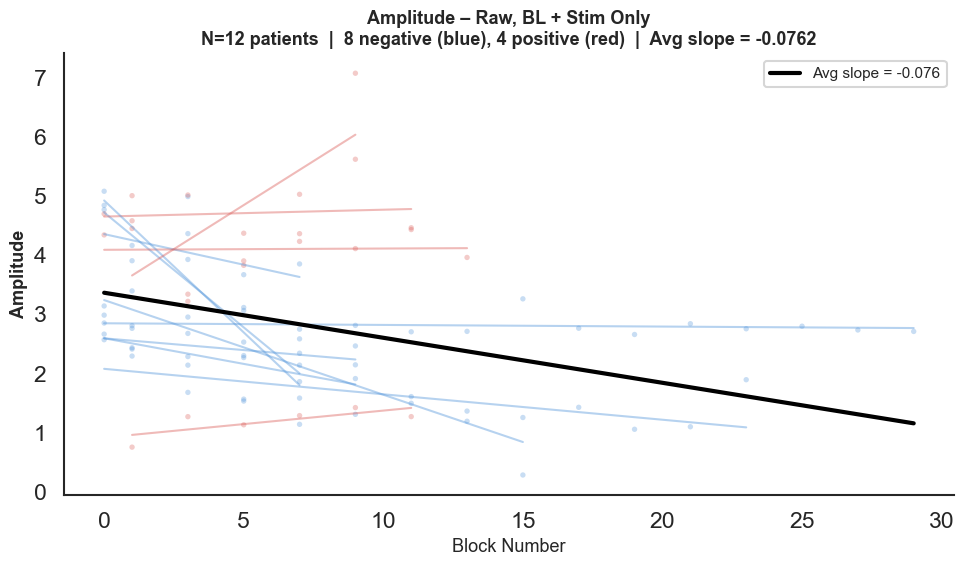


Per-patient slopes for: Amplitude – Raw, BL + Stim Only
  485: -0.3888 (-)
  486: -0.1037 (-)
  487: +0.0116 (+)
  488: +0.0021 (+)
  497: -0.0028 (-)
  498: -0.0430 (-)
  499: -0.1601 (-)
  505: -0.0398 (-)
  5107: -0.0868 (-)
  515: +0.0457 (+)
  520: -0.4463 (-)
  545: +0.2977 (+)
  --- Average: -0.0762


In [11]:
# 2) Raw, BL + stim only
plot_patient_slopes(df_amp, 'amplitude',
    title='Amplitude – Raw, BL + Stim Only',
    ylabel='Amplitude',
    block_filter='stim_only')

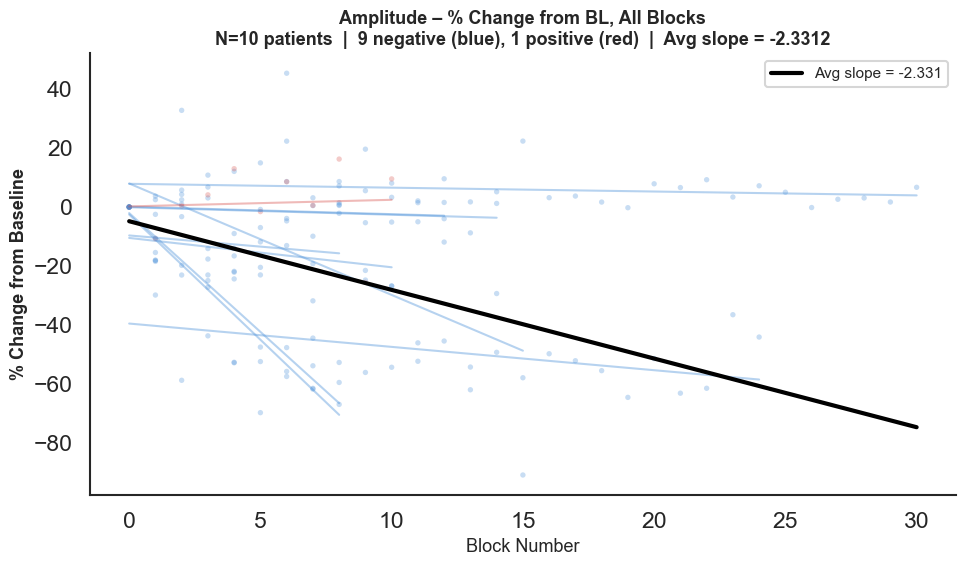


Per-patient slopes for: Amplitude – % Change from BL, All Blocks
  485: -8.0678 (-)
  486: -0.7580 (-)
  487: -0.2539 (-)
  488: -0.2541 (-)
  497: -0.1309 (-)
  498: -0.7920 (-)
  499: -3.7844 (-)
  505: +0.2252 (+)
  5107: -0.9962 (-)
  520: -8.5000 (-)
  --- Average: -2.3312


In [12]:
# 3) Baseline-normalized %, all blocks
plot_patient_slopes(df_amp, 'amplitude',
    title='Amplitude – % Change from BL, All Blocks',
    ylabel='% Change from Baseline',
    normalize='baseline_pct', exclude_no_bl=True)

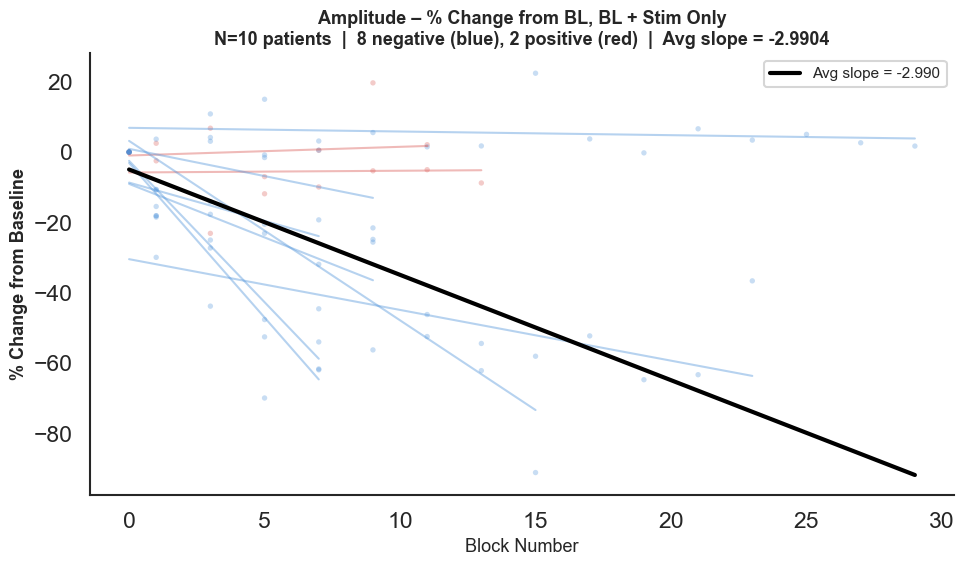


Per-patient slopes for: Amplitude – % Change from BL, BL + Stim Only
  485: -8.0253 (-)
  486: -2.1723 (-)
  487: +0.2465 (+)
  488: +0.0493 (+)
  497: -0.1042 (-)
  498: -1.4407 (-)
  499: -5.0933 (-)
  505: -1.5456 (-)
  5107: -3.0393 (-)
  520: -8.7789 (-)
  --- Average: -2.9904


In [13]:
# 4) Baseline-normalized %, BL + stim only
plot_patient_slopes(df_amp, 'amplitude',
    title='Amplitude – % Change from BL, BL + Stim Only',
    ylabel='% Change from Baseline',
    block_filter='stim_only',
    normalize='baseline_pct', exclude_no_bl=True)

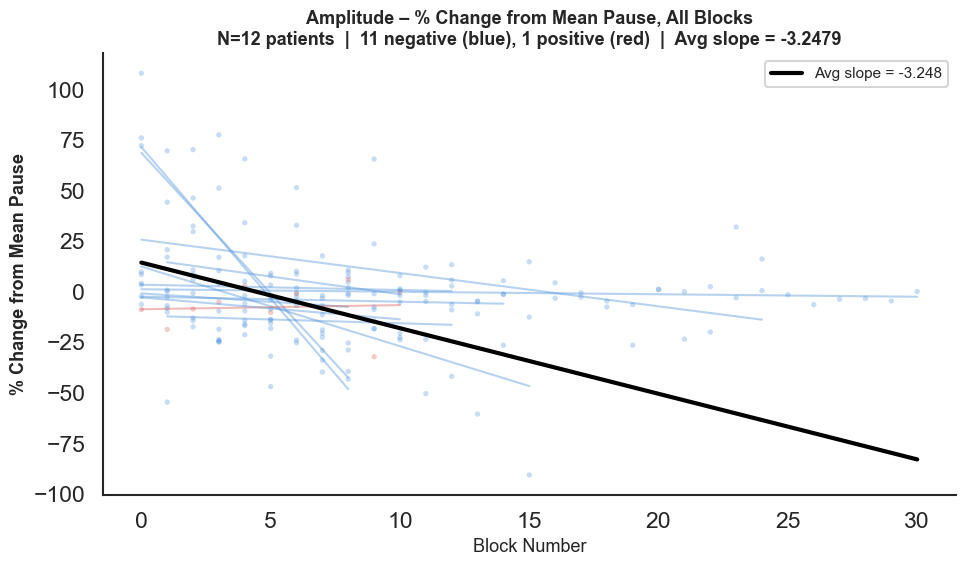


Per-patient slopes for: Amplitude – % Change from Mean Pause, All Blocks
  485: -13.9122 (-)
  486: -0.8331 (-)
  487: -0.2628 (-)
  488: -0.2484 (-)
  497: -0.1229 (-)
  498: -1.6497 (-)
  499: -3.9465 (-)
  505: +0.2056 (+)
  5107: -1.0828 (-)
  515: -0.3771 (-)
  520: -14.9811 (-)
  545: -1.7640 (-)
  --- Average: -3.2479


In [14]:
# 5) Pause-normalized %, all blocks
plot_patient_slopes(df_amp, 'amplitude',
    title='Amplitude – % Change from Mean Pause, All Blocks',
    ylabel='% Change from Mean Pause',
    normalize='pause_pct')

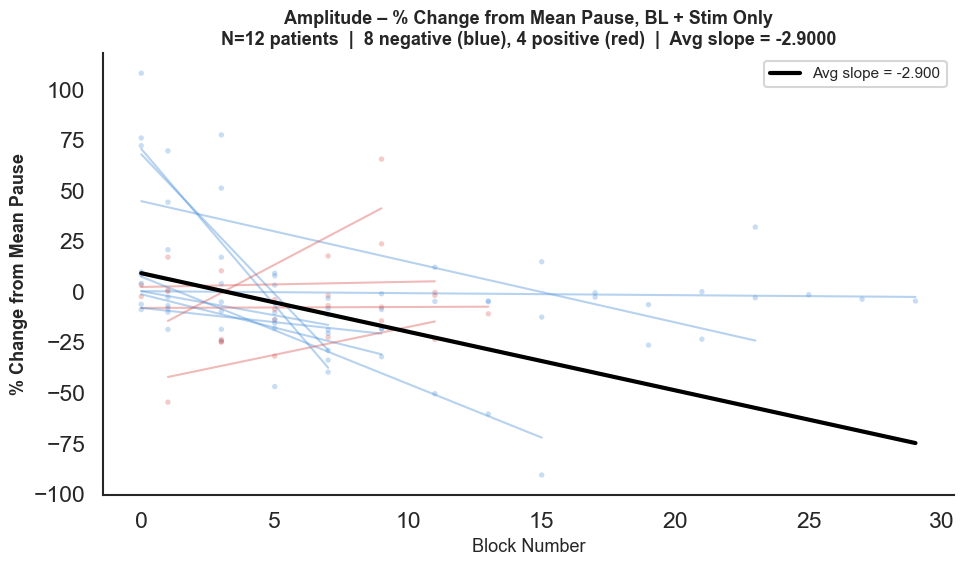


Per-patient slopes for: Amplitude – % Change from Mean Pause, BL + Stim Only
  485: -13.8389 (-)
  486: -2.3875 (-)
  487: +0.2551 (+)
  488: +0.0481 (+)
  497: -0.0979 (-)
  498: -3.0007 (-)
  499: -5.3114 (-)
  505: -1.4108 (-)
  5107: -3.3037 (-)
  515: +2.7500 (+)
  520: -15.4727 (-)
  545: +6.9704 (+)
  --- Average: -2.9000


In [15]:
# 6) Pause-normalized %, BL + stim only
plot_patient_slopes(df_amp, 'amplitude',
    title='Amplitude – % Change from Mean Pause, BL + Stim Only',
    ylabel='% Change from Mean Pause',
    block_filter='stim_only',
    normalize='pause_pct')